## <center> Clustering Antarctic Penguin Species <center>

In [1]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline

In [2]:
# Import the dataset
df = pd.read_csv("C:/Users/uyen/Desktop/Real-World-Projects/Python/datasets/penguins.csv")
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [3]:
df.shape

(332, 5)

In [122]:
df["sex"].unique()

array(['MALE', 'FEMALE'], dtype=object)

In [123]:
# One hot encoding the 'sex' column
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[["sex"]])
one_hot_df = pd.DataFrame(one_hot_encoded, columns = encoder.get_feature_names_out(["sex"]))

In [124]:
# Append the encoded dataframe to the original dataframe
df_encoded = pd.concat([df, one_hot_df], axis = 1)
df_encoded = df_encoded.drop("sex", axis = 1)
df_encoded.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,1.0,0.0
2,40.3,18.0,195.0,3250.0,1.0,0.0
3,36.7,19.3,193.0,3450.0,1.0,0.0
4,39.3,20.6,190.0,3650.0,0.0,1.0


c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

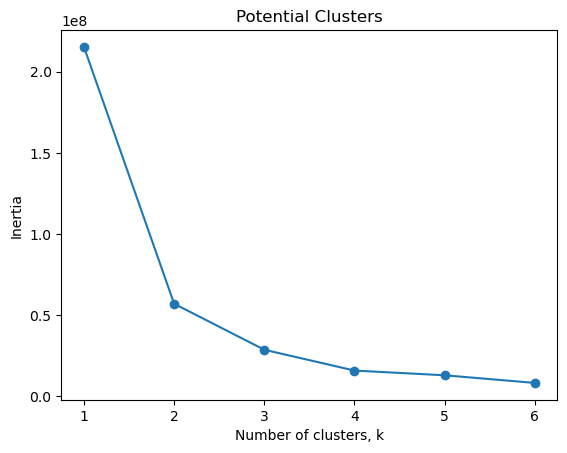

In [125]:
# Determine the number of clusters
ks = range(1, 7)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters
    model = KMeans(n_clusters = k)
    # Fit model to samples
    model.fit(df_encoded)
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot the ks vs inertia
plt.plot(ks, inertias, '-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.title("Potential Clusters")
plt.show()

In [126]:
# Make a pipeline to scale and fit data into clusters
#Create scaler
scaler = StandardScaler()

#Create KMeans instance
kmeans = KMeans(n_clusters = 3, random_state=42)

#Create pipepline
pipeline = make_pipeline(scaler, kmeans)

In [127]:
#Fit the pipeline to samples
pipeline.fit(df_encoded)

# Calculate the cluster labels
labels = pipeline.predict(df_encoded)
df_labeled = pd.DataFrame({"labels": labels})

c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [128]:
# Concat the labels back to the original dataframe
df_clustered = pd.concat([df, df_labeled], axis = 1)
df_clustered.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,labels
0,39.1,18.7,181.0,3750.0,MALE,0
1,39.5,17.4,186.0,3800.0,FEMALE,2
2,40.3,18.0,195.0,3250.0,FEMALE,2
3,36.7,19.3,193.0,3450.0,FEMALE,2
4,39.3,20.6,190.0,3650.0,MALE,0


In [ ]:
# Calculate the average measurements of each cluster
stat_penguins = df_clustered.groupby('labels')[["culmen_length_mm","culmen_depth_mm", "flipper_length_mm", "body_mass_g"]].mean()
stat_penguins = stat_penguins.transpose()

In [130]:
stat_penguins

labels,0,1,2
culmen_length_mm,43.878302,47.568067,40.217757
culmen_depth_mm,19.111321,14.996639,17.611215
flipper_length_mm,194.764151,217.235294,189.046729
body_mass_g,4006.603774,5092.436975,3419.158879
